# TSLA Implied Volatility Surface
## From Raw Options Data to Market Skew and Term Structure

This notebook builds a complete **Implied Volatility (IV) surface** for Tesla (TSLA) options from raw end-of-day data (2019–2022).

**Core Question:** What does the options market tell us about expected future volatility — and where does the Black-Scholes constant-volatility assumption break down?

**Pipeline:**
1. Clean raw TSLA options data → 647K+ liquid quotes after filtering
2. Compute IV via Black-Scholes inversion using a hybrid Newton-Bisection solver
3. Build and visualize the IV surface across strikes and maturities
4. Extract volatility skew and term structure
5. Run an event study: the August 2020 TSLA stock split

**Dataset:** TSLA daily EOD options quotes, 2019–2022 | **Risk-Free Rate:** 3.9%

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

sns.set_style('darkgrid')

In [2]:
class OptionSurfacePreprocessor:
    def __init__(self, df: pd.DataFrame):
        self.df = df.copy()
        self._standardize_columns()

    def _standardize_columns(self):
        """Standardizes column names to lowercase and removes brackets."""
        self.df.columns = [
            str(col).replace('[', '').replace(']', '').strip().lower() 
            for col in self.df.columns
        ]

    def _clean_numeric(self, col_name):
        """Handles whitespace and forces numeric types."""
        if col_name in self.df.columns:
            self.df[col_name] = pd.to_numeric(
                self.df[col_name].astype(str).str.strip(), errors='coerce'
            )

    def process(self, min_dte_years=0.02, max_dte_years=1.0, strike_dist_pct=0.4):
        # 1. Date Conversion & Time to Expiration (tte)
        self.df['quote_date'] = pd.to_datetime(self.df['quote_date'])
        self.df['expire_date'] = pd.to_datetime(self.df['expire_date'])
        self.df['tte'] = (self.df['expire_date'] - self.df['quote_date']).dt.days / 365

        # 2. Numeric Cleaning for TSLA pricing columns
        cols_to_fix = ['c_bid', 'c_ask', 'p_bid', 'p_ask', 'underlying_last', 'strike', 'c_volume']
        for col in cols_to_fix:
            self._clean_numeric(col)

        # 3. Mid-Price Calculation (baseline for IV)
        self.df['c_mid'] = (self.df['c_bid'] + self.df['c_ask']) / 2
        self.df['p_mid'] = (self.df['p_bid'] + self.df['p_ask']) / 2

        # 4. Bid-Ask Spread Filter (Liquidity Guard)
        # Filters out stale quotes where the spread is too wide relative to price.
        self.df['c_spread_pct'] = (self.df['c_ask'] - self.df['c_bid']) / self.df['c_mid']

        # 5. Liquidity Mask — combines distance/time filters with spread and volume requirements
        mask = (
            (self.df['c_bid'] > 0.5) &                                  # Filter out penny options / no bids
            (self.df['tte'] >= min_dte_years) &                          # Remove unstable near-term IV
            (self.df['tte'] <= max_dte_years) &                          # Focus on tradeable horizon
            (abs(self.df['strike_distance_pct']) <= strike_dist_pct) &   # Focus on the smile region
            (self.df['c_volume'] > 0) &                                  # Ensure actual trading activity
            (self.df['c_spread_pct'] < 0.20)                             # Reject illiquid wide spreads
        )
        
        self.df = self.df[mask].dropna(subset=['c_mid']).copy()

        # 6. Add Moneyness (K/S) for Surface Plotting
        self.df['moneyness'] = self.df['strike'] / self.df['underlying_last']

        # 7. Memory & Type Optimization
        self._optimize_types()
        
        return self.df

    def _optimize_types(self):
        """Downcasts to float32 for performance in vectorized IV functions."""
        float_cols = self.df.select_dtypes(include=['float']).columns
        self.df[float_cols] = self.df[float_cols].astype('float32')

    def save_to_parquet(self, filename: str):
        """Saves the optimized dataframe to a compressed Parquet file."""
        self.df.to_parquet(filename, compression='snappy')
        print(f"Saved optimized data to {filename}")

In [3]:
class BlackScholes:
    """
    Black-Scholes option pricing model.

    Parameters:
    S (float/array): spot price
    K (float/array): strike price
    sigma (float/array): volatility
    t (float/array): time to expiration (years)
    r (float): risk-free interest rate
    """

    @staticmethod
    def _calculate_d1_d2(S, K, sigma, t, r):
        d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * t) / (sigma * np.sqrt(t))
        d2 = d1 - sigma * np.sqrt(t)
        return d1, d2

    def call_price(self, S, K, sigma, t, r):
        d1, d2 = self._calculate_d1_d2(S, K, sigma, t, r)
        return S * norm.cdf(d1) - np.exp(-r * t) * K * norm.cdf(d2)

    def vega(self, S, K, sigma, t, r):
        d1, _ = self._calculate_d1_d2(S, K, sigma, t, r)
        return S * np.sqrt(t) * norm.pdf(d1)

    @staticmethod
    def call_iv_vectorized(market_prices, spots, strikes, ttes, r,
                            sigma0=0.2, max_iter=100, tol=1e-8):
        """
        Vectorized IV solver using a Hybrid Newton-Bisection method.
        - Newton-Raphson for fast convergence in well-behaved regions
        - Falls back to bisection when vega is too small or Newton step escapes bounds
        - Arbitrage pre-filter rejects prices outside (S - Ke^{-rT}, S)
        """
        bs = BlackScholes()
        data_length = len(market_prices)
        sigmas    = np.full(data_length, sigma0, dtype='float')
        sigmas_lo = np.full(data_length, 0.05,   dtype='float')
        sigmas_hi = np.full(data_length, 8.0,    dtype='float')
        converged = np.zeros(data_length, dtype=bool)

        # Arbitrage Boundary Check
        lower = spots - np.exp(-r * ttes) * strikes
        upper = spots
        valid = (market_prices > lower) & (market_prices < upper)
        sigmas[~valid] = np.nan

        # Optimization Loop
        for _ in range(max_iter):
            active = valid & ~converged
            if not np.any(active):
                break

            idx = np.where(active)[0]
            prices_a = bs.call_price(spots[idx], strikes[idx], sigmas[idx], ttes[idx], r)
            errors   = prices_a - market_prices[idx]

            just_converged = np.abs(errors) < tol
            converged[idx[just_converged]] = True

            active = valid & ~converged
            idx = np.where(active)[0]
            if len(idx) == 0:
                break

            # Update brackets
            new_lows  = errors[~just_converged] < 0
            new_highs = errors[~just_converged] > 0
            sigmas_lo[idx] = np.where(new_lows,  sigmas[idx], sigmas_lo[idx])
            sigmas_hi[idx] = np.where(new_highs, sigmas[idx], sigmas_hi[idx])

            # Newton step with bisection fallback
            vegas          = bs.vega(spots[idx], strikes[idx], sigmas[idx], ttes[idx], r)
            sigmas_newton  = sigmas[idx] - errors[~just_converged] / np.maximum(vegas, 1e-6)
            sigmas_mid     = (sigmas_lo[idx] + sigmas_hi[idx]) * 0.5

            use_mid    = (vegas < 1e-6) | (sigmas_newton < sigmas_lo[idx]) | (sigmas_newton > sigmas_hi[idx])
            sigmas[idx] = np.where(use_mid, sigmas_mid, sigmas_newton)

        sigmas[~converged] = np.nan
        return sigmas, converged

## Step 1: Data Cleaning

Raw TSLA options data contains messy column names, missing values, and illiquid quotes. The `OptionSurfacePreprocessor` filters down to liquid, tradeable options:

| Filter | Criteria | Purpose |
|--------|----------|---------|
| Bid price | > $0.50 | Remove penny options with no real market |
| Time to expiry | 7 days – 1 year | Focus on tradeable horizon; removes expiry-day noise |
| Strike distance | < 40% from spot | Keep the smile region; deep OTM/ITM quotes are unreliable |
| Volume | > 0 | Only options with actual trading activity |
| Bid-ask spread | < 20% of mid | Reject stale, wide-spread quotes |

Result: **647,480 liquid quotes** from 2.6M raw rows.

In [4]:
import os
import pandas as pd

if os.path.exists('tsla_2019_2022.csv'):
    # Load raw TSLA data
    df_tsla = pd.read_csv('tsla_2019_2022.csv', low_memory=False)

    processor = OptionSurfacePreprocessor(df_tsla)

    df_clean = processor.process(
        min_dte_years=0.02,
        max_dte_years=1.0,
        strike_dist_pct=0.4
    )

    processor.save_to_parquet('tsla_optimized.parquet')

    print("-" * 40)
    print(f"Pipeline complete.")
    print(f"Total valid quotes: {len(df_clean):,}")
    print(f"Date range: {df_clean['quote_date'].min().date()} → {df_clean['quote_date'].max().date()}")
    print("-" * 40)
else:
    print("File not found. Please ensure 'tsla_2019_2022.csv' is in the current directory.")

Saved optimized data to tsla_optimized.parquet
----------------------------------------
Pipeline complete.
Total valid quotes: 647,480
Date range: 2019-01-02 → 2022-12-30
----------------------------------------


## Step 2: Implied Volatility Calculation

For each liquid option, we invert the Black-Scholes formula to find the **implied volatility (IV)** — the market's forward-looking volatility estimate embedded in the option price.

**Method:** Hybrid Newton-Bisection solver
- Newton-Raphson for fast convergence in well-behaved regions
- Automatic fallback to bisection when vega < 1e-6 or the Newton step escapes the valid bounds
- Arbitrage pre-filter: rejects prices outside `(S - Ke^{-rT}, S)`
- Tolerance: `1e-8` | Max iterations: `100`

This produces **638,197 valid IV estimates** across the full dataset, with an average IV of **66.70%**.

In [5]:
# 1. Load the cleaned dataset
df = pd.read_parquet('tsla_optimized.parquet')

# 2. Risk-Free Rate — 3.9% (approximate 2019–2022 average)
R_FREE_RATE = 0.039

# 3. Prepare NumPy arrays for vectorized computation
market_prices = df['c_mid'].values
spots         = df['underlying_last'].values
strikes       = df['strike'].values
ttes          = df['tte'].values

# 4. Run the hybrid Newton-Bisection IV solver
iv_values, converged_mask = BlackScholes.call_iv_vectorized(
    market_prices=market_prices,
    spots=spots,
    strikes=strikes,
    ttes=ttes,
    r=R_FREE_RATE
)

# 5. Attach results to dataframe
df['iv']           = iv_values
df['iv_converged'] = converged_mask

# 6. Drop non-converged rows
df_final = df.dropna(subset=['iv']).copy()

# 7. Save
df_final.to_parquet('tsla_with_iv.parquet')

print(f"IV calculated for {len(df_final):,} liquid TSLA options.")
print(f"Average Implied Volatility: {df_final['iv'].mean():.2%}")

IV calculated for 638,197 liquid TSLA options.
Average Implied Volatility: 66.70%


## Step 3: The IV Surface — Reality vs. Black-Scholes Theory

We take a snapshot of the full TSLA options chain at market close on the last available date and plot IV as a function of **moneyness (K/S)** and **time to expiration (TTE)**.

The **gray plane** overlaid on the surface represents what Black-Scholes assumes: a single, constant volatility for every strike and maturity. The **colored surface** is what the market actually prices.

Selected Snapshot:  2022-12-30 16:00 with 343 points.
Plotting 343 points for 2022-12-30


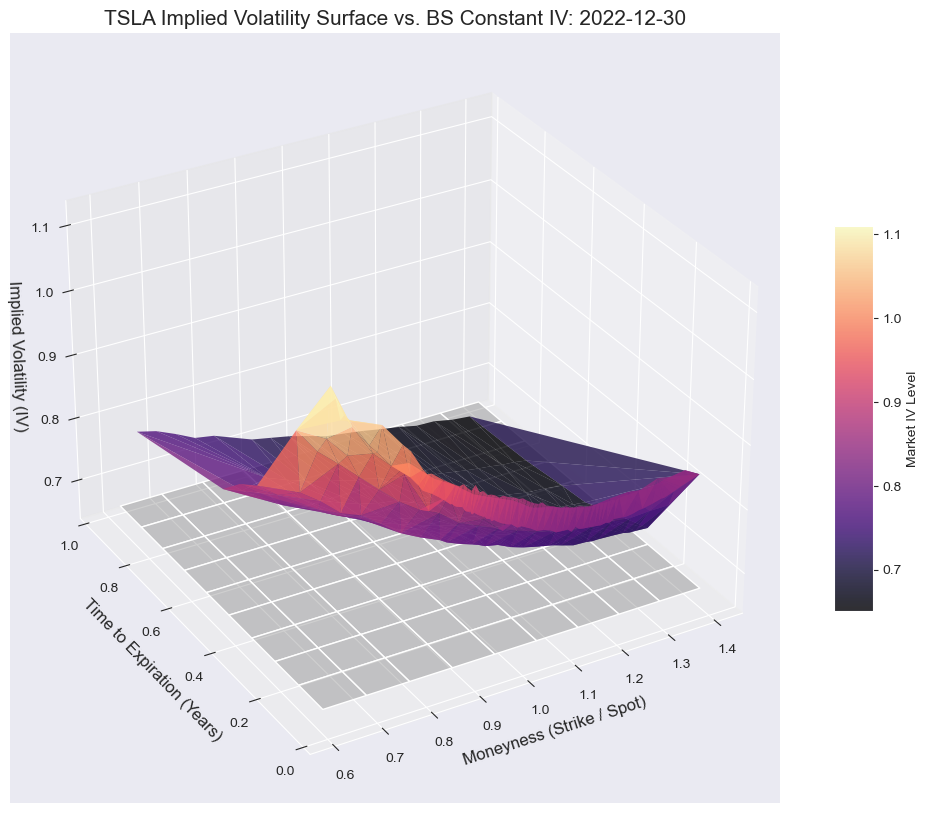

In [6]:
# 0. Load the data with your calculated IV
df = pd.read_parquet('tsla_with_iv.parquet')

# 1. Get the very last date available in your data
last_date = df['quote_date'].max()

# 2. Find all unique timestamps for that day
available_times = df[df['quote_date'] == last_date]['quote_readtime'].unique()

# 3. Select the very last available time of that day (usually the close)
if len(available_times) > 0:
    last_time = available_times[-1] # Grabs the last string in the list
    snapshot = df[(df['quote_date'] == last_date) & (df['quote_readtime'] == last_time)].copy()
    print(f"Selected Snapshot: {last_time} with {len(snapshot)} points.")
else:
    print(f"No data found for {last_date}")

# 4. Final verification before plotting
print(f"Plotting {len(snapshot)} points for {last_date.date()}")

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np


if len(snapshot) >= 3:
    fig = plt.figure(figsize=(14, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    x = snapshot['moneyness']
    y = snapshot['tte']
    z = snapshot['iv']
    
    # 1. Plot the Market IV Surface (The "Reality")
    surf = ax.plot_trisurf(x, y, z, cmap='magma', edgecolor='none', alpha=0.8)

    # --- NEW: BLACK-SCHOLES CONSTANT IV PLANE (The "Theory") ---
    # Calculate the average IV as the 'Constant' baseline
    avg_iv = df['iv'].mean() 
    
    # Create a coordinate grid that covers the same area as your data
    x_range = np.linspace(x.min(), x.max(), 10)
    y_range = np.linspace(y.min(), y.max(), 10)
    X_grid, Y_grid = np.meshgrid(x_range, y_range)
    Z_flat = np.full(X_grid.shape, avg_iv) # Every point on this plane is the average IV

    # Plot the flat plane
    # alpha=0.3 makes it transparent so you can see where the market surface 'pokes' through
    ax.plot_surface(X_grid, Y_grid, Z_flat, color='gray', alpha=0.3, label=f'BS Constant IV ({avg_iv:.2%})')
    # -----------------------------------------------------------

    ax.set_title(f'TSLA Implied Volatility Surface vs. BS Constant IV: {last_date.date()}', fontsize=15)
    ax.set_xlabel('Moneyness (Strike / Spot)', fontsize=12)
    ax.set_ylabel('Time to Expiration (Years)', fontsize=12)
    ax.set_zlabel('Implied Volatility (IV)', fontsize=12)
    
    fig.colorbar(surf, shrink=0.5, aspect=10, label='Market IV Level')
    ax.view_init(elev=30, azim=-120)
    
    plt.show()
else:
    print("Error: Still not enough data points.")



### Observation: The Market Smiles, Not Flat

The gray plane is what Black-Scholes assumes: one constant volatility across all strikes and maturities. The colored surface is what the market actually prices — and the difference is stark.

**Key features visible in the surface:**
- **Put-side elevation (moneyness < 1.0):** OTM puts carry higher IV — the market charges a premium for downside crash protection
- **Short-maturity spike:** Near-term options have higher IV, reflecting greater uncertainty about imminent price moves
- **Smile curvature:** IV is lowest near ATM and rises on both wings

This surface is the empirical signature of **fat tails and skewness** in the return distribution — features that Black-Scholes ignores by assuming log-normality. Models like Heston (stochastic volatility) or SABR were developed specifically to fit this shape.

## Step 4: Comparing Market Regimes

The IV surface encodes the market's collective fear and greed — and its shape shifts dramatically with market regime. Here we compare two historically distinct dates:

- **December 18, 2020 (S&P 500 Inclusion Eve):** TSLA was added to the S&P 500 on December 21. The week prior saw extreme bullish sentiment and elevated options activity on both sides.
- **December 30, 2022 (Year-End Close):** Post-peak correction. TSLA had fallen ~65% from its 2021 highs — a defensive, fearful market with heavy put demand.

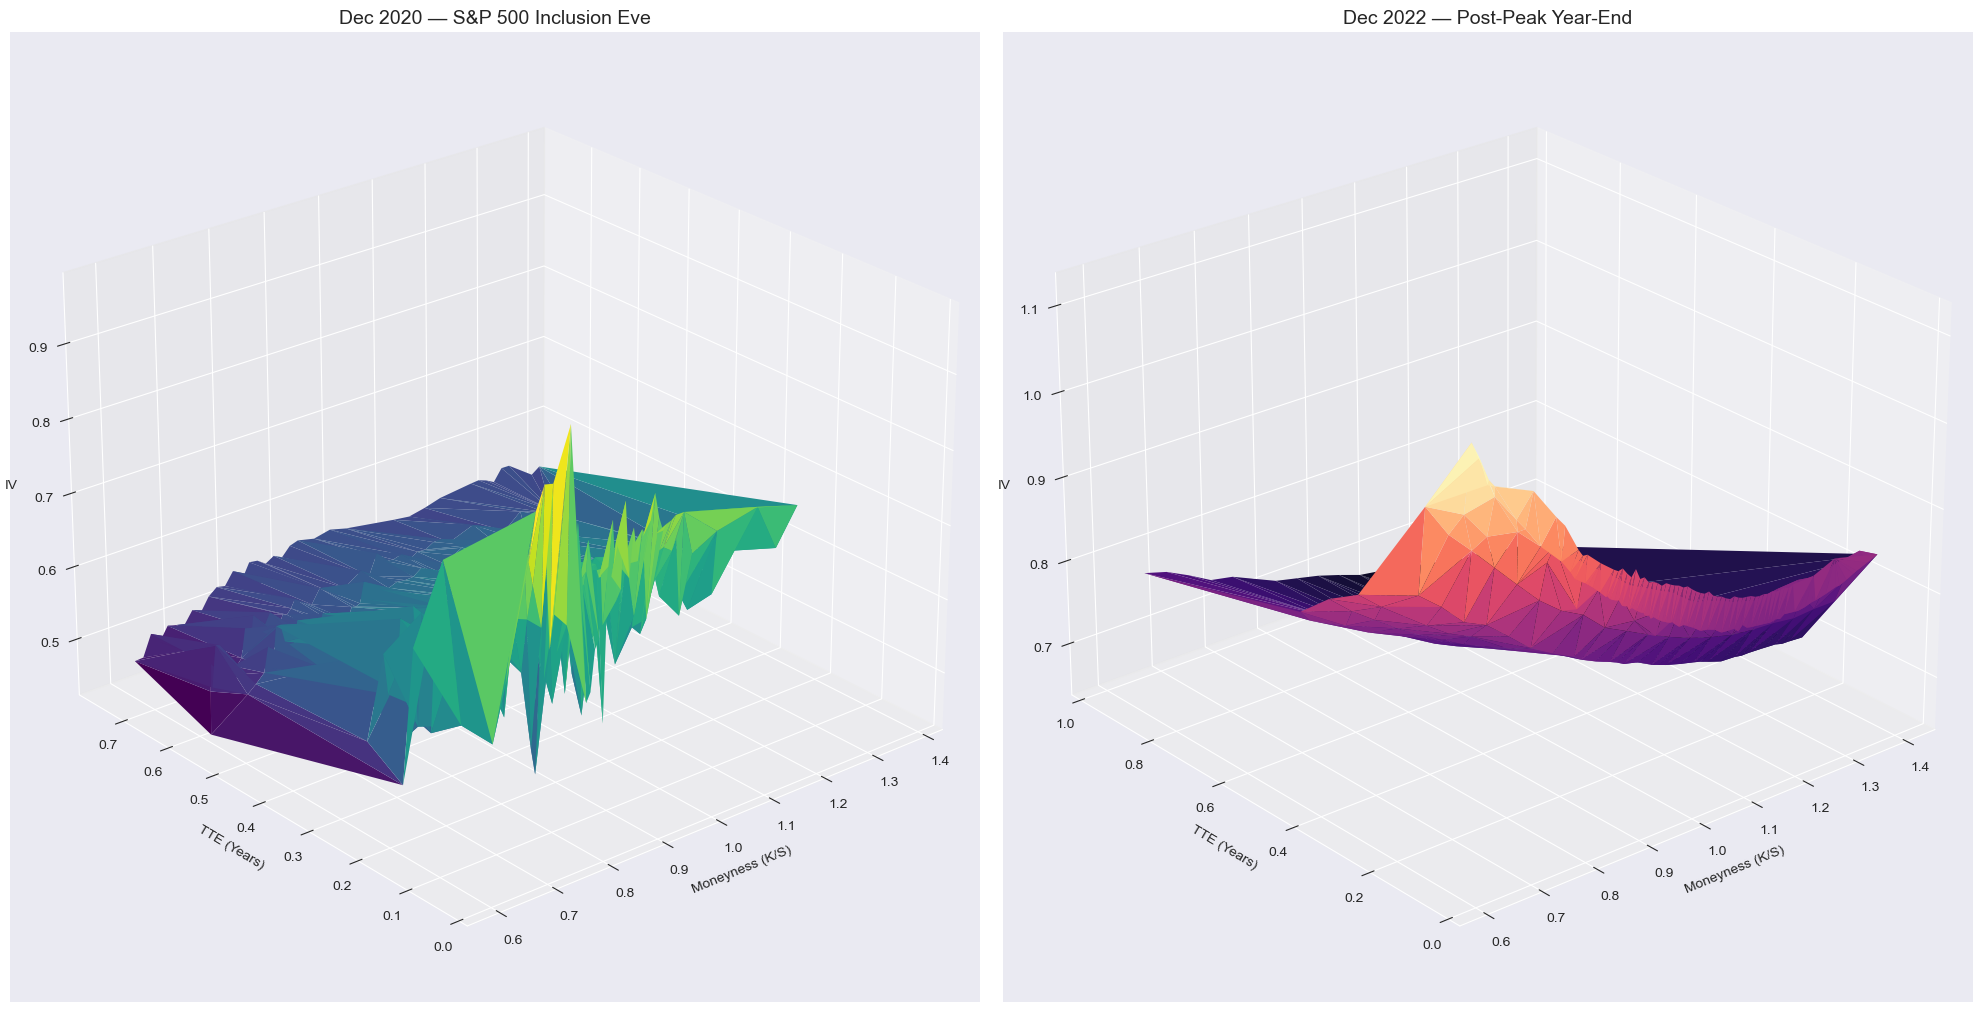

In [7]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def get_clean_snapshot(df, target_date):
    """Returns the EOD (4:00 PM or last available) snapshot for a given date."""
    day_data = df[df['quote_date'] == target_date]
    if day_data.empty:
        return None
    snapshot = day_data[day_data['quote_readtime'].str.contains('4:00 PM')]
    if len(snapshot) < 10:
        last_time = day_data['quote_readtime'].unique()[-1]
        snapshot = day_data[day_data['quote_readtime'] == last_time]
    return snapshot

date_sp500   = '2020-12-18'  # Friday before S&P 500 inclusion Monday
date_yearend = '2022-12-30'  # Last available date in dataset

snap_2020 = get_clean_snapshot(df, date_sp500)
snap_2022 = get_clean_snapshot(df, date_yearend)

fig = plt.figure(figsize=(20, 10))

for i, (snap, title) in enumerate([
    (snap_2020, "Dec 2020 — S&P 500 Inclusion Eve"),
    (snap_2022, "Dec 2022 — Post-Peak Year-End")
]):
    if snap is not None:
        ax = fig.add_subplot(1, 2, i + 1, projection='3d')
        surf = ax.plot_trisurf(snap['moneyness'], snap['tte'], snap['iv'],
                               cmap='viridis' if i == 0 else 'magma', edgecolor='none')
        ax.set_title(title, fontsize=14)
        ax.set_xlabel('Moneyness (K/S)')
        ax.set_ylabel('TTE (Years)')
        ax.set_zlabel('IV')
        ax.view_init(elev=25, azim=-130)

plt.tight_layout()
plt.show()

### Observation: Surface Shape Shifts With Market Regime

The two surfaces tell different stories:

- **2020 (S&P 500 inclusion eve):** Elevated overall IV driven by an extraordinary event. The surface is more symmetric — both puts and calls were actively bid, reflecting two-way uncertainty around an unprecedented index rebalancing.
- **2022 (post-peak correction):** Steeper put-skew dominates. After a ~65% drawdown, the market was paying heavily for downside protection. The right wing (OTM calls) is relatively flat — nobody was chasing upside.

**Insight:** The *level* of IV tells you how much uncertainty exists. The *shape* tells you which direction the market fears most.

## Step 5: The Volatility Smile — One Expiry, Full Picture

Slicing the 3D surface at a single expiration date gives the classic **volatility smile**: a 2D curve showing how IV varies across moneyness. This is the most direct visualization of the market's deviation from Black-Scholes constant-vol assumption.

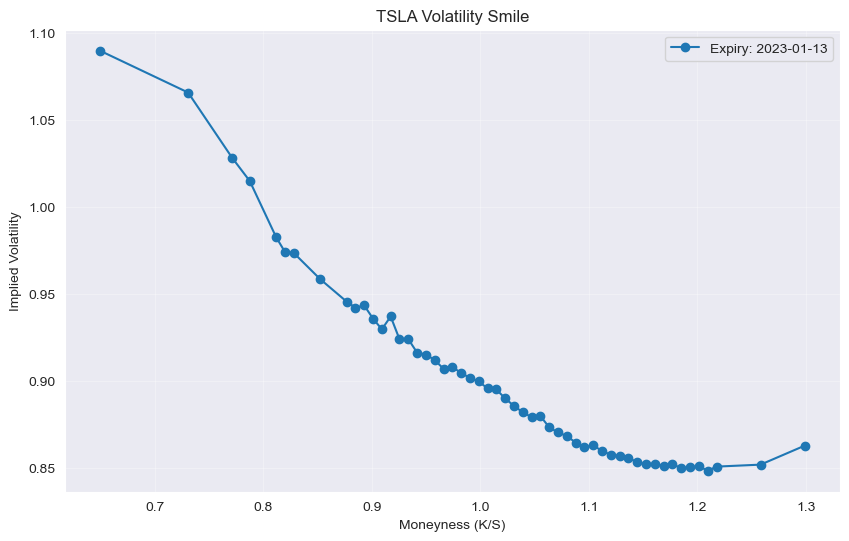

In [8]:
# Pick one expiration from your snapshot
single_expiry = snapshot[snapshot['expire_date'] == snapshot['expire_date'].iloc[0]]

plt.figure(figsize=(10, 6))
plt.plot(single_expiry['moneyness'], single_expiry['iv'], 'o-', label=f"Expiry: {single_expiry['expire_date'].iloc[0].date()}")
plt.xlabel('Moneyness (K/S)')
plt.ylabel('Implied Volatility')
plt.title('TSLA Volatility Smile')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Step 6: Skew & Term Structure — Two Dimensions of Risk

The IV surface can be decomposed into two key market signals:

**Volatility Skew** *(fixed maturity, varying strike)*: How IV changes across strikes for a given expiration. A downward-sloping skew — higher IV for lower strikes — is the market's *crash insurance premium*.

**Term Structure** *(ATM options, varying maturity)*: How ATM IV changes across maturities. A downward-sloping curve means the market expects near-term stress to resolve over time.

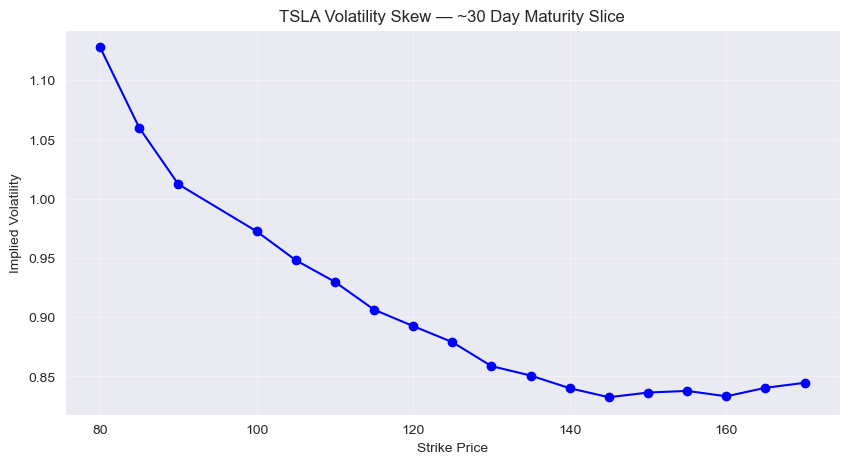

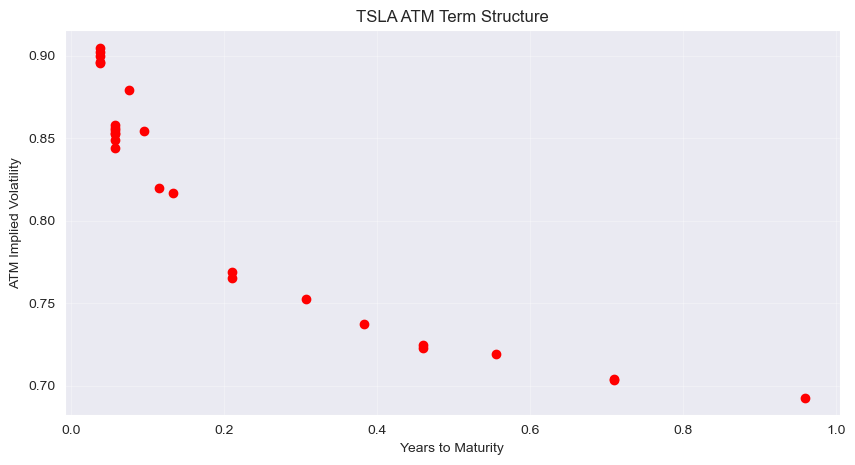

In [9]:
import matplotlib.pyplot as plt

df = pd.read_parquet('tsla_with_iv.parquet')
snapshot = df[df['quote_date'] == '2022-12-30']

# --- 1. VOLATILITY SKEW ---
expiry_30d = snapshot[snapshot['tte'].between(0.07, 0.09)]

plt.figure(figsize=(10, 5))
plt.plot(expiry_30d['strike'], expiry_30d['iv'], 'bo-')
plt.title("TSLA Volatility Skew — ~30 Day Maturity Slice")
plt.xlabel("Strike Price")
plt.ylabel("Implied Volatility")
plt.grid(True, alpha=0.3)
plt.show()

# --- 2. TERM STRUCTURE ---
atm_options = snapshot[snapshot['moneyness'].between(0.98, 1.02)]

plt.figure(figsize=(10, 5))
plt.scatter(atm_options['tte'], atm_options['iv'], color='red')
plt.title("TSLA ATM Term Structure")
plt.xlabel("Years to Maturity")
plt.ylabel("ATM Implied Volatility")
plt.grid(True, alpha=0.3)
plt.show()

### Interpreting the Signals

**Skew:** The negative slope confirms a classic **put skew** — as strike falls below ATM, IV rises sharply. This is the market pricing in left-tail risk: a large, sudden drawdown. The steeper the skew, the more the market fears a crash. This premium is sometimes called the **variance risk premium**.

**Term Structure:** ATM IV typically declines with maturity (downward sloping = near-term stress expected to resolve). An *inverted* term structure — where short-dated IV exceeds long-dated IV — is a sign of acute near-term fear, often seen around earnings, macro events, or market crashes.

Together, skew and term structure are the two core tools for assessing **directional and temporal risk sentiment** from options data.

## Step 7: Event Study — TSLA Stock Split (August 2020)

TSLA announced a **5-for-1 stock split** on August 11, 2020. What followed was one of the most dramatic options market events in recent memory.

Normally, **put skew dominates**: OTM puts are expensive because investors buy downside protection. During the split run-up, retail traders aggressively bid up **OTM calls**, creating a rare **reverse skew** — call-side IV spiked above put-side IV.

We track the volatility smile across four key dates, all targeting the **September 18, 2020** expiration:

| Date | Event |
|------|-------|
| Aug 11 | Split announcement — baseline |
| Aug 21 | Record date — excitement building |
| Aug 28 | Peak hype — last trading day before split |
| Aug 31 | Post-split — event resolves, IV collapses |

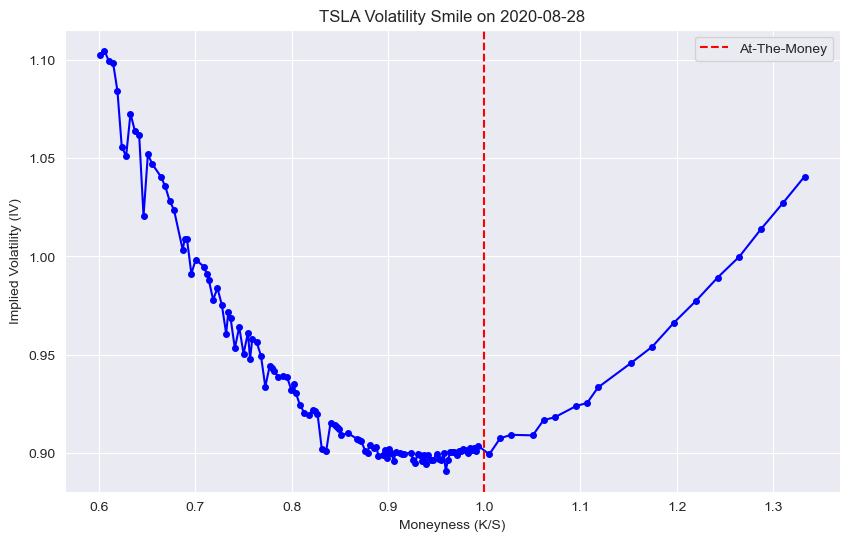

In [10]:
# Select ONE specific snapshot date and ONE specific expiration
target_date = '2020-08-28' # Peak hype before the split
target_expiry = '2020-09-18'

# Filter for that exact combination
smile_data = df[(df['quote_date'] == target_date) & 
                 (df['expire_date'] == target_expiry)].copy()

# CRITICAL: Sort by moneyness so the line connects correctly
smile_data = smile_data.sort_values('moneyness')

# Plot the SMILE
plt.figure(figsize=(10, 6))
plt.plot(smile_data['moneyness'], smile_data['iv'], 'bo-', markersize=4)

# Add the ATM line as a reference
plt.axvline(1.0, color='red', linestyle='--', label='At-The-Money')

plt.title(f'TSLA Volatility Smile on {target_date}')
plt.xlabel('Moneyness (K/S)')
plt.ylabel('Implied Volatility (IV)')
plt.legend()
plt.show()

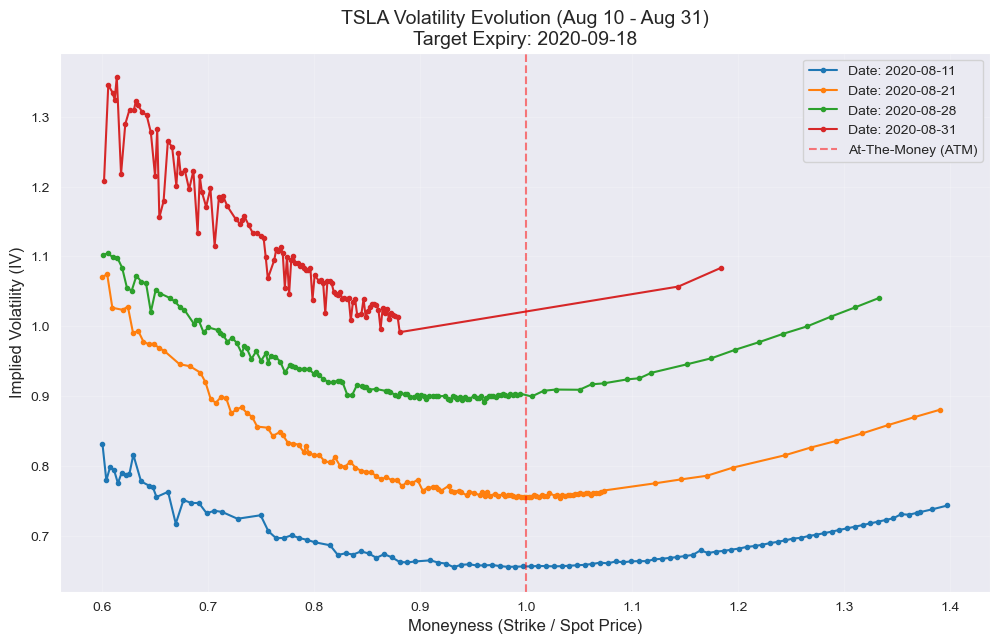

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load data
df = pd.read_parquet('tsla_with_iv.parquet')

# 2. Setup the dates we want to compare
# Aug 11: Announcement | Aug 21: Record Date | Aug 28: Peak Hype | Aug 31: Split Effective
dates_to_compare = ['2020-08-11', '2020-08-21', '2020-08-28', '2020-08-31']

# 3. Select a consistent Monthly Expiration (Sept 18, 2020)
target_expiry = '2020-09-18'

plt.figure(figsize=(12, 7))

for q_date in dates_to_compare:
    # Filter for the day and expiration
    # We use .contains() to handle potential time-string mismatches
    day_data = df[(df['quote_date'] == q_date) & 
                  (df['expire_date'] == target_expiry)].copy()
    
    if not day_data.empty:
        # SORT by moneyness to ensure the lines connect correctly
        day_data = day_data.sort_values('moneyness')
        
        # Plot each date as a new line
        plt.plot(day_data['moneyness'], day_data['iv'], 'o-', label=f'Date: {q_date}', markersize=3)

# 4. Final Polish
plt.axvline(1.0, color='red', linestyle='--', alpha=0.5, label='At-The-Money (ATM)')
plt.title(f'TSLA Volatility Evolution (Aug 10 - Aug 31)\nTarget Expiry: {target_expiry}', fontsize=14)
plt.xlabel('Moneyness (Strike / Spot Price)', fontsize=12)
plt.ylabel('Implied Volatility (IV)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

### What This Tells Us

The smile shifted from a standard **left-skew** (puts expensive, crash fear) toward a **right-skew** (calls expensive, FOMO-driven) as the split date approached. By August 31, IV collapsed sharply as the event uncertainty resolved — a textbook **post-event volatility crush**.

---

## Key Takeaways

1. **Black-Scholes is empirically wrong** — the market prices a smile, not a flat surface; constant-vol is a simplification that fails in practice
2. **Skew encodes fear** — the put premium is a direct, real-time measure of crash risk appetite and tail hedging demand
3. **Term structure encodes timing** — where on the maturity curve IV is elevated tells you *when* the market expects stress
4. **The surface is dynamic** — it shifts with regime, sentiment, and events; monitoring its shape is as important as its level
5. **Events distort the surface** — the 2020 split is a case study in how microstructure and retail positioning can flip the skew entirely

The IV surface is not just a pricing tool — it is a window into the market's collective expectations, fears, and positioning.